In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import os
from pathlib import Path
from scipy.spatial.distance import cosine
from scipy.stats import spearmanr
import pickle
import matplotlib.pyplot as plt


In [2]:
perturbationStrength=pd.read_csv("./../../TextFiles/perturbation_by_drug_nsig_genes_fdr_lt_0p1.csv", index_col=0)

FileNotFoundError: [Errno 2] No such file or directory: 'perturbation_by_drug_nsig_genes_fdr_lt_0p1.csv'

In [3]:
# Load the rowbound matrix produced by notebook 10's "looser filters" cell:
#   - rows: PosteriorMean_matrix_<drug>::<perturbation> for the union of perts
#           significant in ≥1 drug context (1,933 perts × 16 drugs)
#   - cols: response genes with MEDIAN-across-drugs > 40 (~14,639 genes)
# This cell loads it as `a` (drug::pert × gene); the next cell transposes for
# the gene-embedding pipeline.
a = pd.read_csv(
    "/home/beraslan/Projects/ChemoGeneticScreens/TextFiles/PosteriorMeanMatrices_rowbound_anyDrugSig_geneMed40.csv",
    index_col=0,
)
print(a.shape)

(30704, 14639)


In [4]:
a

,SFRP1,APOE,TUBB2B,PDLIM1,COL6A1,TPM1,POU5F1,AASS,SERPINB9,FTL,...,BMP8B,RGS19,FRMD3,ANKS1A,OR2L2,THSD7B,AP4S1,MYL11,KLRG1,BCL2
PosteriorMean_matrix_AR-A014418::A1BG,0.019141,0.001280,-0.003251,0.003372,0.004118,0.002244,0.005220,0.000936,0.000756,-0.000096,...,0.000161,-0.000278,-0.000033,-0.001630,0.000018,0.000038,-0.000490,-0.000099,0.000037,-0.000187
PosteriorMean_matrix_AR-A014418::AASS,0.005622,-0.037648,-0.039193,0.000646,0.006335,0.001698,0.011338,-2.547604,0.000018,0.000579,...,0.000073,0.000080,0.000592,0.000794,-0.000556,-0.000163,0.000720,0.000141,0.000437,-0.000612
PosteriorMean_matrix_AR-A014418::ABCB6,0.000297,0.000286,-0.000155,-0.002614,-0.001033,0.000032,-0.000139,-0.004492,0.001876,-0.004256,...,0.000086,0.000012,0.000085,-0.000356,-0.000020,0.000066,0.000289,0.000225,-0.000070,-0.000435
PosteriorMean_matrix_AR-A014418::ABCC5,0.028030,-0.000482,-0.000040,-0.000463,0.023774,0.000157,0.000047,-0.000506,0.001478,-0.000222,...,0.000075,-0.000166,-0.000538,0.000130,-0.000556,-0.000093,0.000213,-0.000099,0.000930,0.000560
PosteriorMean_matrix_AR-A014418::ABCF3,-0.085573,-0.007372,-0.025086,-0.000795,0.093550,-0.054777,0.016131,0.053351,0.003076,0.003075,...,-0.000104,-0.000325,-0.000091,-0.000930,0.000105,-0.000126,-0.002549,-0.000042,-0.007025,-0.000100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PosteriorMean_matrix_VX-11e::ZSCAN21,-0.001577,0.175078,0.001494,0.227127,-0.137962,0.001452,-0.358448,-0.405158,-0.120059,0.220939,...,-0.001502,-0.023397,-0.000112,0.000470,-0.000113,-0.000367,0.000079,-0.000121,0.000032,-0.005639
PosteriorMean_matrix_VX-11e::ZSCAN32,-0.760627,0.305753,-0.005756,0.327601,0.598942,-0.387090,0.189496,-0.000184,0.901250,0.277669,...,0.000046,0.000261,-0.000056,0.011598,-0.000113,0.000045,0.000093,-0.000002,-0.000835,-0.000582
PosteriorMean_matrix_VX-11e::ZW10,-1.730701,0.185776,-0.001264,0.185225,0.143567,-0.999123,0.401471,-0.508788,1.377752,0.537161,...,-0.001502,-0.129787,0.000128,-0.028946,-0.000113,-0.007925,-0.039779,-0.002342,0.000100,-0.035899
PosteriorMean_matrix_VX-11e::ZXDC,-0.639408,0.211522,0.112127,0.230960,0.211719,-0.290019,0.009831,-0.218596,0.588651,0.355775,...,0.000117,-0.000331,-0.010950,0.000045,-0.000113,-0.000578,-0.010184,0.000048,0.000650,-0.000400


In [5]:
a=a.T

In [6]:
# Create AnnData object
adata = sc.AnnData(X=a.values.copy())
adata.obs_names = a.index
adata.var_names = a.columns

# Scale genes (columns) to zero mean and unit variance
sc.pp.scale(adata)  # max_value clips extreme values

# Generate embeddings
sc.tl.pca(adata, n_comps=250)

# Build neighbor graph
sc.pp.neighbors(
    adata,
    n_neighbors=5,
    use_rep="X_pca",
)

/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
sc.tl.umap(adata)


/tmp/ipykernel_3955531/4113376048.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=2.0, key_added="leiden")


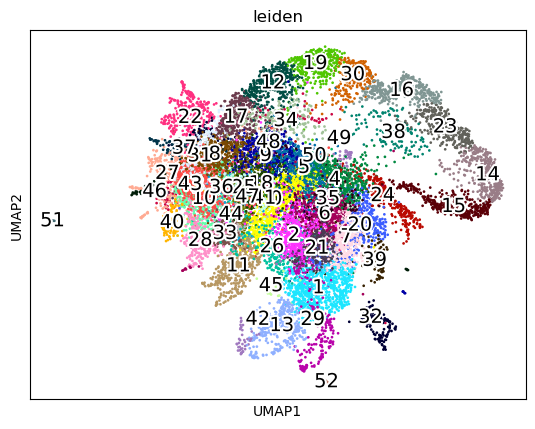

In [8]:
sc.tl.leiden(adata, resolution=2.0, key_added="leiden")

sc.pl.umap(adata, 
           color='leiden',
           size=15,  
           legend_fontoutline=3, 
           legend_loc = 'on data',
           legend_fontsize=14,
           legend_fontweight='normal')


In [49]:
adata.obs["GeneName"] = adata.obs.index

In [50]:
df=adata.obs[["leiden", "GeneName"]]

In [51]:
df=df.sort_values("leiden")

In [52]:
df.to_csv("GeneModules_all.csv")

In [46]:
df=df.loc[df.leiden.isin(['27','11','20','22','3','4','50','54','38','53',
                      '25','43','15','43','42','24','12','31']),:]

In [48]:
df.to_csv("GeneModules_v1.csv")